#AAI6610 Wine Clustering Assignment

## Comparing K-Means and Agglomerative Clustering on UCI Wine Dataset

This notebook applies two clustering algorithms to the UCI ML Wine Dataset to analyze how well unsupervised methods can recover the three wine cultivar classes.

**Author:** Michael  
**Course:** AAI6610 Applied Machine Learning  
**Date:** February 2026


## Setup: Library Imports


In [2]:
# -- Setup Imports --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Visualization helpers
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# For loading the wine dataset
from sklearn.datasets import load_wine

print("All necessary libraries imported successfully.")
print("-" * 50)

All necessary libraries imported successfully.
--------------------------------------------------


### Data Loading & Exploration

In [3]:
'''
Load the UCI Wine Dataset using sklearn's built-in method.
The dataset contains 178 samples with 13 chemical analysis features
from three different wine cultivars (classes 0, 1, 2).

Note: We load the true labels for EVALUATION ONLY, not for training.
Clustering is unsupervised - we don't use labels to form clusters.
'''

# load the wine dataset 
wine = load_wine()

# create the dataframe with features 
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Store true labels for evaluation 
true_labels = wine.target

# Display the dataframe shape 
print("Wine Dataset Loaded Successfully.")
print("=" * 50)
print(f'Wine Dataframe Shape: {df_wine.shape}')
print(f'Number of Samples: {df_wine.shape[0]}')
print(f'Number of Features: {df_wine.shape[1]}')
print("-" * 50)

# display the feature names 
print("Feature Names in the Wine Dataset:")
for i, name in enumerate(wine.feature_names):
    print(f'{i + 1}. {name}')
    
print("-" * 50)
# true class distribution 
print("True Class Distribution in the Wine Dataset:")
class_counts = pd.Series(true_labels).value_counts().sort_index()

''' used a for loop instead of print for bette formatting and i was unable know for sure how many classes there are. 
pd.series helped with this and the loop formatted it
'''
for cls, count in class_counts.items():
    print(f'Class {cls}: {count} samples')
    

Wine Dataset Loaded Successfully.
Wine Dataframe Shape: (178, 13)
Number of Samples: 178
Number of Features: 13
--------------------------------------------------
Feature Names in the Wine Dataset:
1. alcohol
2. malic_acid
3. ash
4. alcalinity_of_ash
5. magnesium
6. total_phenols
7. flavanoids
8. nonflavanoid_phenols
9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline
--------------------------------------------------
True Class Distribution in the Wine Dataset:
Class 0: 59 samples
Class 1: 71 samples
Class 2: 48 samples


In [4]:
# quick data exploration 
print("First 5 rows of the dataset:")
print(df_wine.head())
print("=" * 85)
print("Statistical Summary of the Dataset:")
print(df_wine.describe())
print("-" * 50)


First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

### Data Processing 

In [5]:
'''
Standardize the features with mean and variance scaling

Need to standardize because clustering algorithms are distance-based:
- K-Means uses Euclidean distance, which is sensitive to scale

- most features have different ranges in scale, we can StandardScaler to transform the features 
to have a mean of 0 and standard deviation of 1.
'''

# Initialize the StandardScaler 
scaler = StandardScaler()

# fit the scaler to the dataframe and transform it 
df_wine_scaled = scaler.fit_transform(df_wine)


# ----- Verify Standardization worked -----
print("Data standardization complete.\n")
print(f'Scaled data shape: {df_wine_scaled.shape}')
print("=" * 50)

# Mean and Std deviation of scaled features 
print('Mean of scaled features (should be ~0):')
print(f'Mean of first feature (alcohol): {np.mean(df_wine_scaled[:, 0]):.5f}')
print(f'Std of first feature (alcohol): {np.std(df_wine_scaled[:, 0]):.5f}')


# Convert back to DataFrame for easier analysis


Data standardization complete.

Scaled data shape: (178, 13)
Mean of scaled features (should be ~0):
Mean of first feature (alcohol): -0.00000
Std of first feature (alcohol): 1.00000


### 1st Model Implementation: K-Means Clustering

In [6]:
'''
Applying K-Means clustering with k=3 ( since there are a confirmed 3 true classes)

- intialize the KMeans model with 3 clusters
- assign each point to the nearest cluster
- random_state for reproducibility
- repeat until convergence 
'''

# initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, n_init=10, random_state=2026)

# fit and predict the model to the scaled data, Kmeans uses only features, not true labels
kmeans_labels = kmeans.fit_predict(df_wine_scaled)

# display the clusters 
print("K-Means Clustering Complete.")
print("=" * 50)
print("Cluster Distribution:\n")
cluster_count = pd.Series(kmeans_labels).value_counts().sort_index()
for labels, count in cluster_count.items():
    print(f'Cluster {labels}: {count} samples')
print("=" * 50)
print(f'Cluster Centers (in scaled feature space):\n{kmeans.cluster_centers_}')
print("=" * 50)

K-Means Clustering Complete.
Cluster Distribution:

Cluster 0: 62 samples
Cluster 1: 65 samples
Cluster 2: 51 samples
Cluster Centers (in scaled feature space):
[[ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]
 [-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]]


### 2nd Model Implementation: Agglomerative (Hierarchical) Clustering

In [7]:
# Applying Agglomerative Hierarchical Clustering with n_clusters=3
'''
WHY  I CHOSE AGGLOMERATIVE METHOD FOR THIS DATASET:
- a different clustering approaches gives a broader perspective than just Kmeans alone 
- Dendrograms show hierarchial relationships  bewtween the wine sample types 
- minimizes variance, similair to Kmenas 
- different methods but provide valuable insights in comparsion to Kmeans 

THE ALGORITHM
1) each point starts as its own cluster
2) closest clusters merge based of Ward's method, minimizing variance 
3) repeat until 3 clusters remain 

KEY PARAMETERS 
- n_clusters=3 : 3 clusters 
- ward linkage: minimizes variance within clusters 
- random_state: reproducibility 
- complete: max distance between points 
- single: min distance between points 

'''

# instantiate the Agglomerative Clustering model
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')

# fit and predict the model to the scaled data
agglo_labels = agglo.fit_predict(df_wine_scaled)

# display the clusters 
print("Agglomerative Clustering Complete.")
print("=" * 50)

cluster_count = pd.Series(agglo_labels).value_counts().sort_index()
for labels, count in cluster_count.items():
    print(f'Cluster {labels}: {count} samples')
    

Agglomerative Clustering Complete.
Cluster 0: 58 samples
Cluster 1: 56 samples
Cluster 2: 64 samples


### Visualizations 

##### Dendrogram Hierarchical Clustering

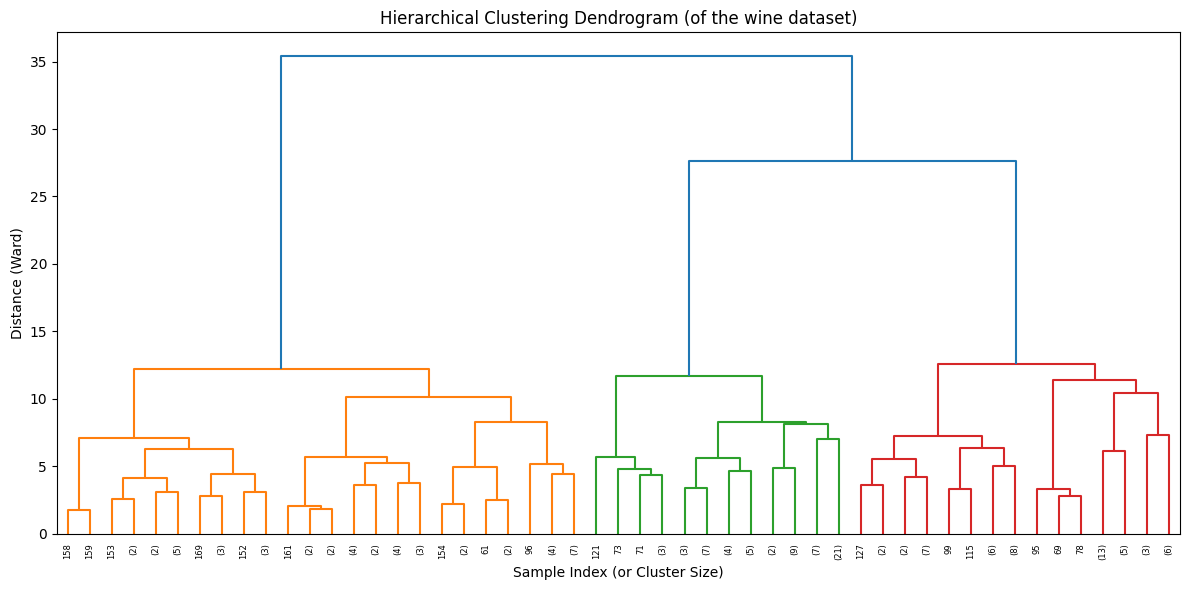

In [8]:
'''
Creating a dendtogram to visualize the hierarchical clustering process
- using scipy's linkage and dendrogram functions 

Shows:
- relationship between samples 
- clusters between different thresholds
- distance at which clusters merge
- groupings
'''

# compute the linkage matrix for the dendrogram. Uses ward method to minimize variance 
linkage_matrix = linkage(df_wine_scaled, method='ward', metric='euclidean')

# create and plot the dendrogram
plt.figure(figsize=(12,6))

# plot the dendrogram
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (of the wine dataset)')
plt.xlabel('Sample Index (or Cluster Size)')
plt.ylabel('Distance (Ward)')

plt.tight_layout()
plt.savefig('wine_dendrogram.png', dpi=300)
plt.show()


##### PCA Scatter plots

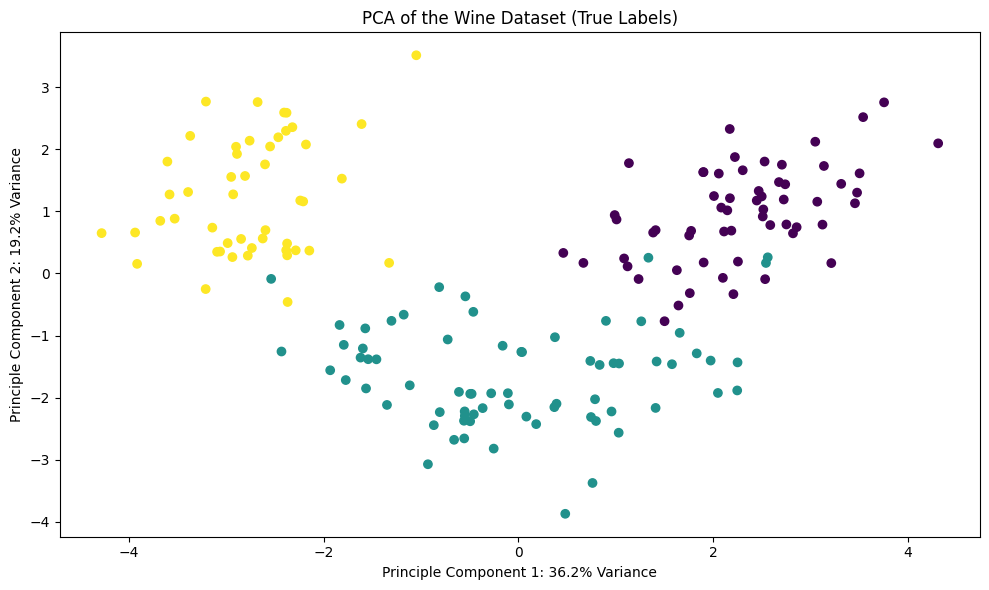

PCA Dimensionality Reduction Complete.
Combined Explained Variance by 2 Principal Components: 55.4%
--------------------------------------------------
PCA Explained Variance Ratios:
Principle Component 1: 36.2% Variance
Principle Component 2: 19.2% Variance


In [9]:
'''
Use PCA for dimensionality reduction to reduce to 2D visualization
'''

# apply PCA to reduce to 2D
pca = PCA(n_components=2, random_state=2026)

# fit and transform the scaled data
pca_df_wine = pca.fit_transform(df_wine_scaled)

# plot the PCA results with true labels 
plt.figure(figsize=(10,6))
plt.scatter(pca_df_wine[:, 0], pca_df_wine[:, 1], c=true_labels)
plt.title('PCA of the Wine Dataset (True Labels)')
plt.xlabel('Principle Component 1: {:.1f}% Variance'.format(pca.explained_variance_ratio_[0]*100))
plt.ylabel('Principle Component 2: {:.1f}% Variance'.format(pca.explained_variance_ratio_[1]*100))

plt.tight_layout()
plt.savefig('wine_pca_true_labels.png', dpi=300)
plt.show()


# ------ Explained Variance Ratio ------
print("PCA Dimensionality Reduction Complete.")
print("=" * 50)
print(f'Combined Explained Variance by 2 Principal Components: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')
print("-" * 50)
print("PCA Explained Variance Ratios:")
print('Principle Component 1: {:.1f}% Variance'.format(pca.explained_variance_ratio_[0]*100))
print('Principle Component 2: {:.1f}% Variance'.format(pca.explained_variance_ratio_[1]*100))

##### Side by Side Comparison

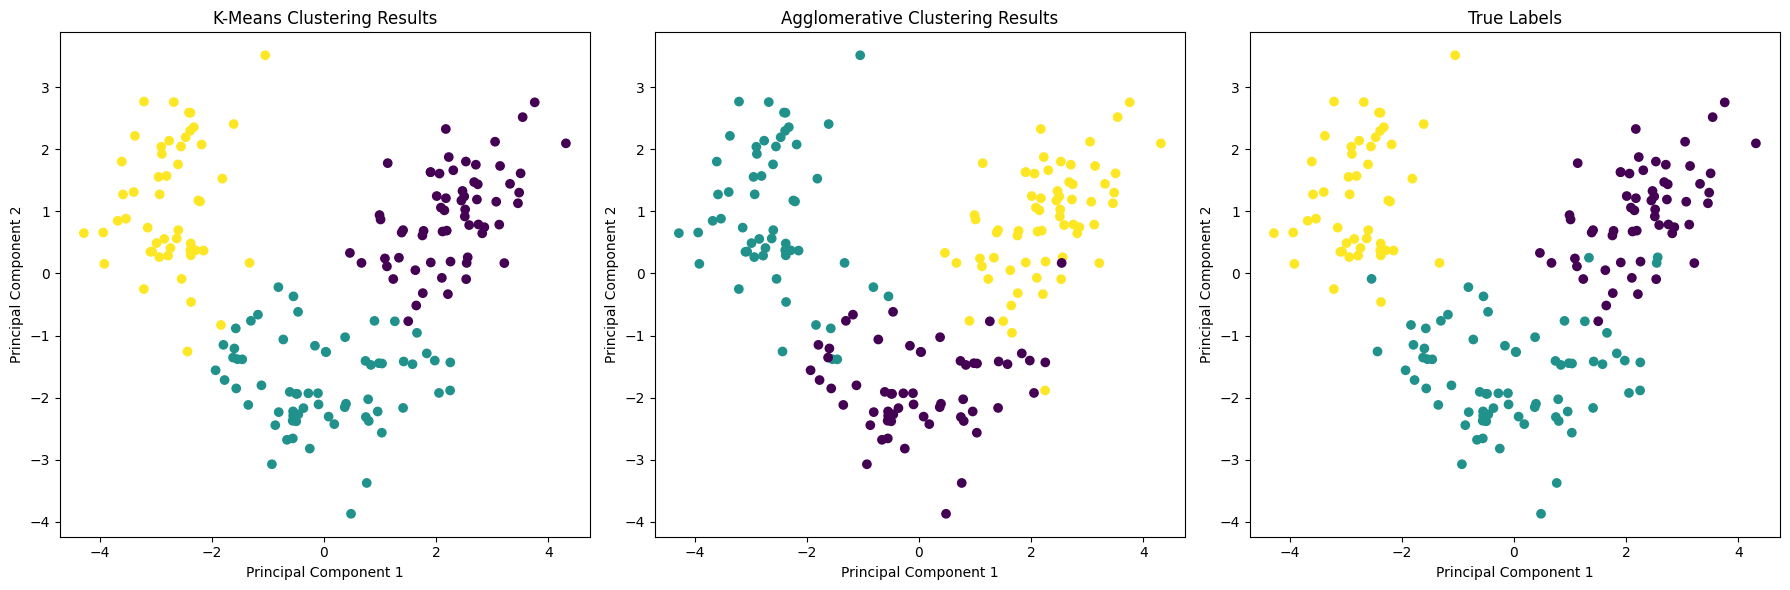

Comparison of Clustering Results Complete and saved as wine_clustering_comparison.png


In [10]:
'''
The goal here is to show a side by side visual comparison of the clsutering results from K-Means and Agglomerative clustering 
Consist of:
1) K-Means Clustering Results 
2) Agglomerative Clustering Results
3) True Labels (for further reference)
'''

# create subplots and set figsize 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ------- PLOT 1: K-Means Clustering Results -------

# c tells us since there are 3 clusters in the array (0, 1, 2) to color each cluster differently
# cmap 'viridis' (yellow-green-purple gradiant) for better visual distinction 
scatter_plot_1 = axes[0].scatter(pca_df_wine[:, 0], pca_df_wine[:, 1], c=kmeans_labels, cmap='viridis')
axes[0].set_title('K-Means Clustering Results')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# ------- PLOT 2: Agglomerative Clustering Results -------
scatter_plot_1 = axes[1].scatter(pca_df_wine[:, 0], pca_df_wine[:, 1], c=agglo_labels, cmap='viridis')
axes[1].set_title('Agglomerative Clustering Results')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# ------- PLOT 3: True Labels -------
scatter_plot_1 = axes[2].scatter(pca_df_wine[:, 0], pca_df_wine[:, 1], c=true_labels, cmap='viridis')
axes[2].set_title('True Labels')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')

# format, save, show the plots 
plt.tight_layout()
plt.savefig('wine_clustering_comparison.png', dpi=300)
plt.show()
print('Comparison of Clustering Results Complete and saved as wine_clustering_comparison.png')

### EVALUATION METRICS

In [20]:
'''
This section will evaluate the metrics of both clustering algorithms


The following metrics will be used:

1 internal metric, that doees not require true labels:
- Silhouette Score 
    - measures how similar points within its own cluster compared to the other clusters 
    - range from -1 to 1, higher is better 


2 external metrics, do have true labels, both use different agreements methods but help match clusters to true labels:
- Adjusted Rand Index (ARI):
    - measures similarity between predicted clusters and true labels
    - range from -1 to 1, 1 is to perfect match and 0 = random
- Normalized Mutual Information (NMI):
    - measures mutual information between predicted clusters and true labels
    - range from 0 to 1, 1 is to perfect match  
'''


# Calculate metrics for K-Means Clustering 
kmeans_silhouette = silhouette_score(df_wine_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

# Calculate metrics for Agglomerative Clustering
agglo_silhouette = silhouette_score(df_wine_scaled, agglo_labels)
agglo_ari = adjusted_rand_score(true_labels, agglo_labels)
agglo_nmi = normalized_mutual_info_score(true_labels, agglo_labels)

# Display Results 
print('Clustering Evaluation Metrics:')
print("=" * 50 + "\n")
# adding padding for better formatting
print(f'{"Metric " :<40} {"K-Means |" :<10} {"Agglomerative" :<15}')
print("-" * 65)
print(f'{"Silhoutte Score " :<40} {kmeans_silhouette:<10.4f} {agglo_silhouette:<15.4f}')
print(f'{"Adjusted Rand Index Score " :<40} {kmeans_ari:<10.4f} {agglo_ari:<15.4f}')
print(f'{"Normalized Mutual Information Score " :<40} {kmeans_nmi:<10.4f} {agglo_nmi:<15.4f}' + '\n')


# ----- Dataframe for easier analysis -----
df_results = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Adjusted Rand Index', 'Normalized Mutual Information'],
    'K-Means': [f"{kmeans_silhouette:.5f}", f"{kmeans_ari:.5f}", f"{kmeans_nmi:.5f}"],
    'Agglomerative': [f"{agglo_silhouette:.5f}", f"{agglo_ari:.5f}", f"{agglo_nmi:.5f}"]
})

df_results['Better'] = df_results.apply(
    lambda row: 'K-Means' if row['K-Means'] > row['Agglomerative'] else 'Agglomerative', 
    axis=1
)

print("=" * 65)
print('Results as a DataFrame:')
print(df_results.to_string(index=False))

Clustering Evaluation Metrics:

Metric                                   K-Means |  Agglomerative  
-----------------------------------------------------------------
Silhoutte Score                          0.2849     0.2774         
Adjusted Rand Index Score                0.8975     0.7899         
Normalized Mutual Information Score      0.8759     0.7865         

Results as a DataFrame:
                       Metric K-Means Agglomerative  Better
             Silhouette Score 0.28486       0.27744 K-Means
          Adjusted Rand Index 0.89749       0.78993 K-Means
Normalized Mutual Information 0.87589       0.78647 K-Means
